<a href="https://colab.research.google.com/github/realmadou/toast/blob/main/Regularization_MLP_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ========================
# Imports
# ========================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ========================
# Load Dataset
# ========================
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ========================
# Model
# ========================
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MLP()

# ========================
# Device
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# ========================
# Loss & Optimizer
# ========================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ========================
# Training Function
# ========================
def train_model(model, train_loader, criterion, optimizer, device, epochs=5):
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100*correct/total:.2f}%")

# ========================
# Evaluation Function
# ========================
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100*correct/total:.2f}%")

# ========================
# Run Training
# ========================
train_model(model, train_loader, criterion, optimizer, device, epochs=5)

# ========================
# Evaluate
# ========================
evaluate_model(model, test_loader, device)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 506kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.00MB/s]


Epoch [1/5], Loss: 0.2830, Accuracy: 91.78%
Epoch [2/5], Loss: 0.1073, Accuracy: 96.76%
Epoch [3/5], Loss: 0.0714, Accuracy: 97.74%
Epoch [4/5], Loss: 0.0507, Accuracy: 98.39%
Epoch [5/5], Loss: 0.0379, Accuracy: 98.76%
Test Accuracy: 97.77%


In [2]:
# =========================================
# Regularization Benchmark on MLPs - MNIST
# Baseline + Validation + Optional Dropout
# =========================================

# --------------------
# Imports
# --------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# --------------------
# Device
# --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# --------------------
# Load MNIST
# --------------------
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# --------------------
# Split into train/validation
# --------------------
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# --------------------
# DataLoaders
# --------------------
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

# --------------------
# MLP Model
# --------------------
class MLP(nn.Module):
    def __init__(self, use_dropout=False):
        super(MLP, self).__init__()

        self.use_dropout = use_dropout

        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten image

        x = F.relu(self.fc1(x))
        if self.use_dropout:
            x = self.dropout(x)

        x = F.relu(self.fc2(x))
        if self.use_dropout:
            x = self.dropout(x)

        x = self.fc3(x)
        return x

# --------------------
# Training Function
# --------------------
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_acc = 100 * train_correct / train_total

        # ---- Validation ----
        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_acc = 100 * val_correct / val_total

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%"
        )

    return train_losses, val_losses, train_accuracies, val_accuracies

# --------------------
# Test Function
# --------------------
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    print(f"Test Accuracy: {test_acc:.2f}%")
    return test_acc

# --------------------
# Baseline Experiment
# --------------------
print("\n--- Baseline MLP (No Dropout) ---")
baseline_model = MLP(use_dropout=False).to(device)
criterion = nn.CrossEntropyLoss()
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

baseline_train_losses, baseline_val_losses, baseline_train_accs, baseline_val_accs = train_model(
    baseline_model, train_loader, val_loader, criterion, baseline_optimizer, device, epochs=5
)

baseline_test_acc = evaluate_model(baseline_model, test_loader, device)

# --------------------
# Dropout Experiment
# --------------------
print("\n--- MLP with Dropout ---")
dropout_model = MLP(use_dropout=True).to(device)
dropout_optimizer = torch.optim.Adam(dropout_model.parameters(), lr=0.001)

dropout_train_losses, dropout_val_losses, dropout_train_accs, dropout_val_accs = train_model(
    dropout_model, train_loader, val_loader, criterion, dropout_optimizer, device, epochs=5
)

dropout_test_acc = evaluate_model(dropout_model, test_loader, device)

# --------------------
# Final Comparison
# --------------------
print("\n--- Final Comparison ---")
print(f"Baseline Test Accuracy: {baseline_test_acc:.2f}%")
print(f"Dropout Test Accuracy:  {dropout_test_acc:.2f}%")

Using device: cpu
Train samples: 48000
Validation samples: 12000
Test samples: 10000

--- Baseline MLP (No Dropout) ---
Epoch [1/5] | Train Loss: 0.3162, Train Acc: 90.83% | Val Loss: 0.1962, Val Acc: 94.07%
Epoch [2/5] | Train Loss: 0.1228, Train Acc: 96.27% | Val Loss: 0.1162, Val Acc: 96.62%
Epoch [3/5] | Train Loss: 0.0780, Train Acc: 97.60% | Val Loss: 0.1066, Val Acc: 96.82%
Epoch [4/5] | Train Loss: 0.0562, Train Acc: 98.23% | Val Loss: 0.0971, Val Acc: 97.28%
Epoch [5/5] | Train Loss: 0.0425, Train Acc: 98.66% | Val Loss: 0.0906, Val Acc: 97.28%
Test Accuracy: 97.49%

--- MLP with Dropout ---
Epoch [1/5] | Train Loss: 0.4782, Train Acc: 85.76% | Val Loss: 0.2019, Val Acc: 93.69%
Epoch [2/5] | Train Loss: 0.2337, Train Acc: 93.21% | Val Loss: 0.1435, Val Acc: 95.60%
Epoch [3/5] | Train Loss: 0.1850, Train Acc: 94.60% | Val Loss: 0.1185, Val Acc: 96.56%
Epoch [4/5] | Train Loss: 0.1611, Train Acc: 95.18% | Val Loss: 0.1076, Val Acc: 96.94%
Epoch [5/5] | Train Loss: 0.1456, Train 

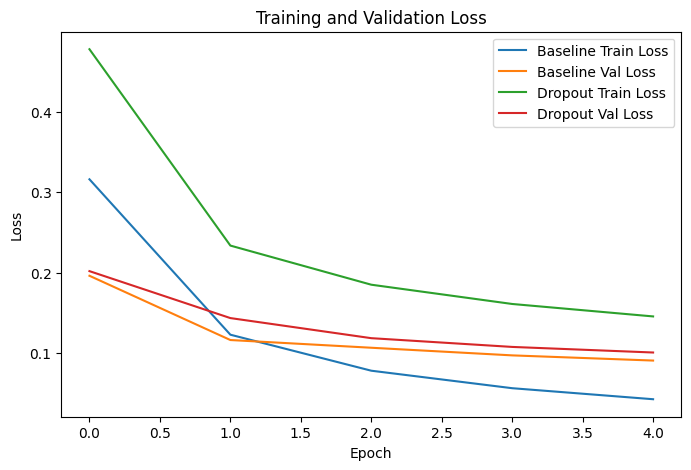

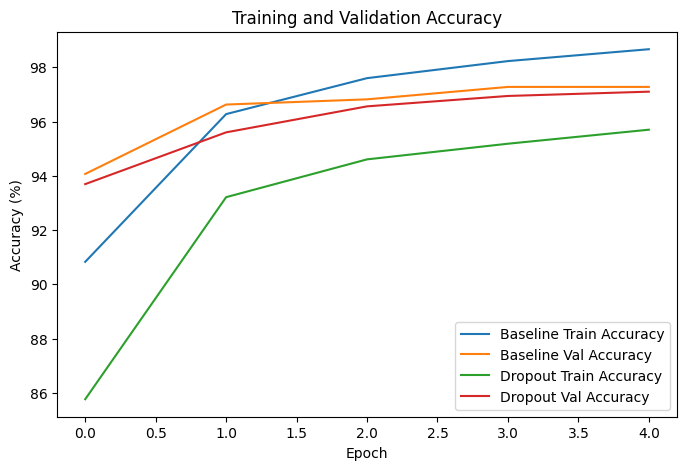

In [3]:
import matplotlib.pyplot as plt

# --------------------
# Plot Loss Curves
# --------------------
plt.figure(figsize=(8, 5))
plt.plot(baseline_train_losses, label='Baseline Train Loss')
plt.plot(baseline_val_losses, label='Baseline Val Loss')
plt.plot(dropout_train_losses, label='Dropout Train Loss')
plt.plot(dropout_val_losses, label='Dropout Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# --------------------
# Plot Accuracy Curves
# --------------------
plt.figure(figsize=(8, 5))
plt.plot(baseline_train_accs, label='Baseline Train Accuracy')
plt.plot(baseline_val_accs, label='Baseline Val Accuracy')
plt.plot(dropout_train_accs, label='Dropout Train Accuracy')
plt.plot(dropout_val_accs, label='Dropout Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


--- MLP with L2 Regularization ---
Epoch [1/5] | Train Loss: 0.3211, Train Acc: 90.94% | Val Loss: 0.1828, Val Acc: 94.75%
Epoch [2/5] | Train Loss: 0.1430, Train Acc: 95.72% | Val Loss: 0.1277, Val Acc: 96.44%
Epoch [3/5] | Train Loss: 0.1075, Train Acc: 96.88% | Val Loss: 0.1270, Val Acc: 96.38%
Epoch [4/5] | Train Loss: 0.0934, Train Acc: 97.20% | Val Loss: 0.1048, Val Acc: 97.04%
Epoch [5/5] | Train Loss: 0.0837, Train Acc: 97.60% | Val Loss: 0.1005, Val Acc: 97.12%
Test Accuracy: 97.33%


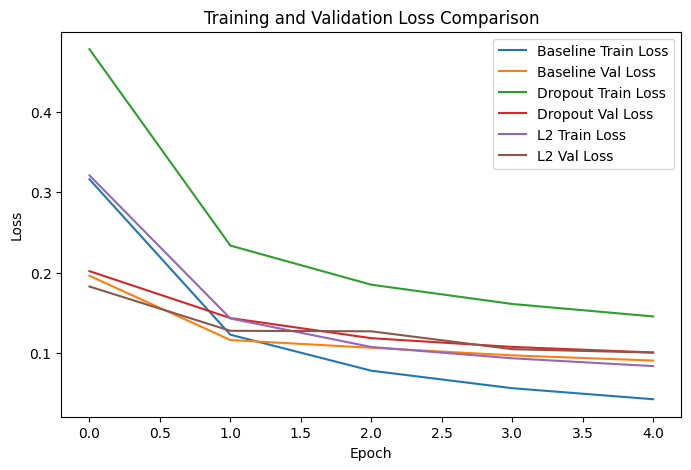

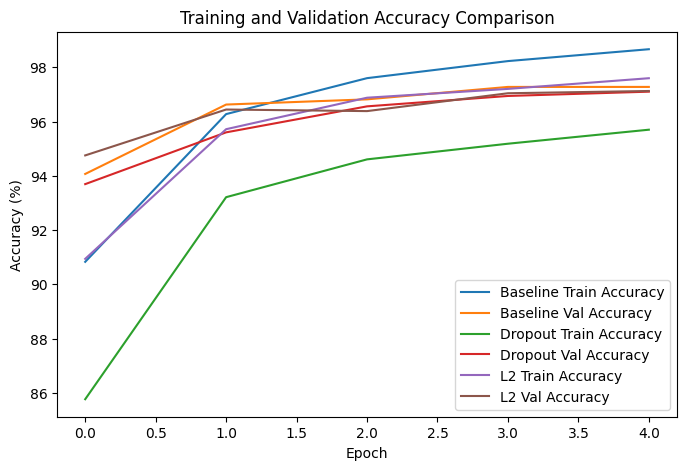


--- Final Test Accuracy Comparison ---
Baseline Test Accuracy: 97.49%
Dropout Test Accuracy:  97.27%
L2 Test Accuracy:       97.33%


In [4]:
# =========================================
# L2 Regularization Experiment + Updated Graphs
# =========================================

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --------------------
# L2 Regularization Experiment
# --------------------
print("\n--- MLP with L2 Regularization ---")

l2_model = MLP(use_dropout=False).to(device)
criterion = nn.CrossEntropyLoss()

# L2 regularization is added through weight_decay
l2_optimizer = torch.optim.Adam(l2_model.parameters(), lr=0.001, weight_decay=0.001)

l2_train_losses, l2_val_losses, l2_train_accs, l2_val_accs = train_model(
    l2_model, train_loader, val_loader, criterion, l2_optimizer, device, epochs=5
)

l2_test_acc = evaluate_model(l2_model, test_loader, device)

# --------------------
# Updated Loss Graph
# --------------------
plt.figure(figsize=(8, 5))
plt.plot(baseline_train_losses, label='Baseline Train Loss')
plt.plot(baseline_val_losses, label='Baseline Val Loss')
plt.plot(dropout_train_losses, label='Dropout Train Loss')
plt.plot(dropout_val_losses, label='Dropout Val Loss')
plt.plot(l2_train_losses, label='L2 Train Loss')
plt.plot(l2_val_losses, label='L2 Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Comparison')
plt.legend()
plt.show()

# --------------------
# Updated Accuracy Graph
# --------------------
plt.figure(figsize=(8, 5))
plt.plot(baseline_train_accs, label='Baseline Train Accuracy')
plt.plot(baseline_val_accs, label='Baseline Val Accuracy')
plt.plot(dropout_train_accs, label='Dropout Train Accuracy')
plt.plot(dropout_val_accs, label='Dropout Val Accuracy')
plt.plot(l2_train_accs, label='L2 Train Accuracy')
plt.plot(l2_val_accs, label='L2 Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Comparison')
plt.legend()
plt.show()

# --------------------
# Final Comparison
# --------------------
print("\n--- Final Test Accuracy Comparison ---")
print(f"Baseline Test Accuracy: {baseline_test_acc:.2f}%")
print(f"Dropout Test Accuracy:  {dropout_test_acc:.2f}%")
print(f"L2 Test Accuracy:       {l2_test_acc:.2f}%")


--- MLP with Early Stopping ---
Epoch [1/15] | Train Loss: 0.3099, Train Acc: 91.20% | Val Loss: 0.1583, Val Acc: 95.42%
Epoch [2/15] | Train Loss: 0.1161, Train Acc: 96.39% | Val Loss: 0.1210, Val Acc: 96.53%
Epoch [3/15] | Train Loss: 0.0768, Train Acc: 97.57% | Val Loss: 0.0922, Val Acc: 97.41%
Epoch [4/15] | Train Loss: 0.0545, Train Acc: 98.28% | Val Loss: 0.1023, Val Acc: 97.14%
Epoch [5/15] | Train Loss: 0.0418, Train Acc: 98.65% | Val Loss: 0.1058, Val Acc: 97.14%
Epoch [6/15] | Train Loss: 0.0318, Train Acc: 99.01% | Val Loss: 0.1179, Val Acc: 97.03%

Early stopping triggered at epoch 6
Test Accuracy: 97.33%


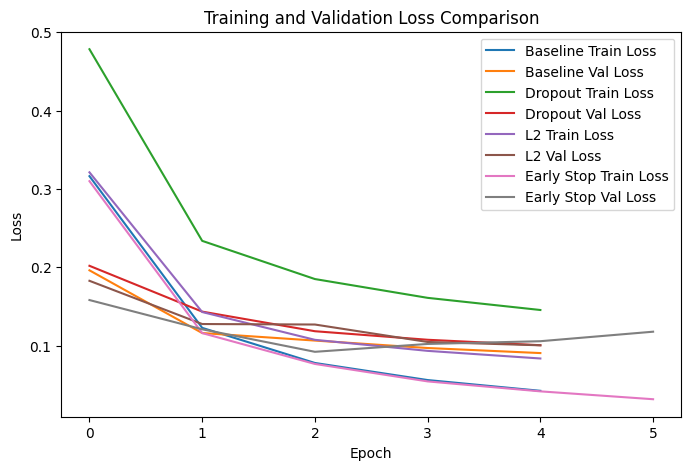

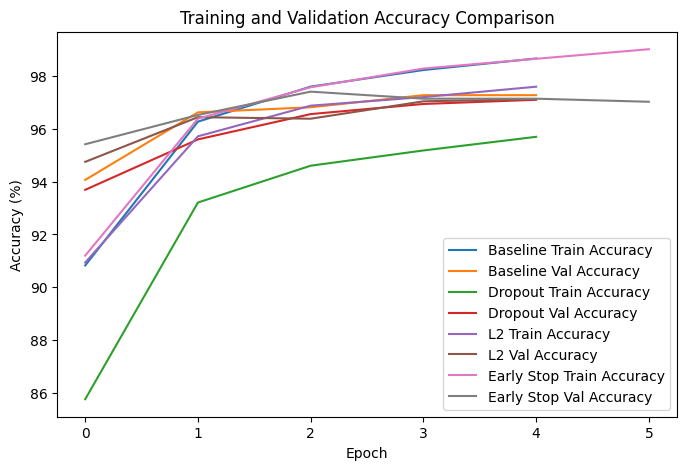


--- Final Test Accuracy Comparison ---
Baseline Test Accuracy:      97.49%
Dropout Test Accuracy:       97.27%
L2 Test Accuracy:            97.33%
Early Stopping Test Accuracy:97.33%


In [5]:
# =========================================
# Early Stopping Experiment + Updated Graphs
# =========================================

import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --------------------
# Training Function with Early Stopping
# --------------------
def train_model_early_stopping(model, train_loader, val_loader, criterion, optimizer, device, epochs=15, patience=3):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_acc = 100 * train_correct / train_total

        # ---- Validation ----
        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_acc = 100 * val_correct / val_total

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%"
        )

        # ---- Early Stopping Check ----
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

    # restore best model
    model.load_state_dict(best_model_weights)

    return train_losses, val_losses, train_accuracies, val_accuracies

# --------------------
# Early Stopping Experiment
# --------------------
print("\n--- MLP with Early Stopping ---")

early_model = MLP(use_dropout=False).to(device)
criterion = nn.CrossEntropyLoss()
early_optimizer = torch.optim.Adam(early_model.parameters(), lr=0.001)

early_train_losses, early_val_losses, early_train_accs, early_val_accs = train_model_early_stopping(
    early_model, train_loader, val_loader, criterion, early_optimizer, device, epochs=15, patience=3
)

early_test_acc = evaluate_model(early_model, test_loader, device)

# --------------------
# Updated Loss Graph
# --------------------
plt.figure(figsize=(8, 5))
plt.plot(baseline_train_losses, label='Baseline Train Loss')
plt.plot(baseline_val_losses, label='Baseline Val Loss')
plt.plot(dropout_train_losses, label='Dropout Train Loss')
plt.plot(dropout_val_losses, label='Dropout Val Loss')
plt.plot(l2_train_losses, label='L2 Train Loss')
plt.plot(l2_val_losses, label='L2 Val Loss')
plt.plot(early_train_losses, label='Early Stop Train Loss')
plt.plot(early_val_losses, label='Early Stop Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Comparison')
plt.legend()
plt.show()

# --------------------
# Updated Accuracy Graph
# --------------------
plt.figure(figsize=(8, 5))
plt.plot(baseline_train_accs, label='Baseline Train Accuracy')
plt.plot(baseline_val_accs, label='Baseline Val Accuracy')
plt.plot(dropout_train_accs, label='Dropout Train Accuracy')
plt.plot(dropout_val_accs, label='Dropout Val Accuracy')
plt.plot(l2_train_accs, label='L2 Train Accuracy')
plt.plot(l2_val_accs, label='L2 Val Accuracy')
plt.plot(early_train_accs, label='Early Stop Train Accuracy')
plt.plot(early_val_accs, label='Early Stop Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Comparison')
plt.legend()
plt.show()

# --------------------
# Final Comparison
# --------------------
print("\n--- Final Test Accuracy Comparison ---")
print(f"Baseline Test Accuracy:      {baseline_test_acc:.2f}%")
print(f"Dropout Test Accuracy:       {dropout_test_acc:.2f}%")
print(f"L2 Test Accuracy:            {l2_test_acc:.2f}%")
print(f"Early Stopping Test Accuracy:{early_test_acc:.2f}%")